In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"D:\code\data\green\ppg_final_features.csv")

In [3]:
df["hr"] = (6e4 / df.rri).astype(int)

In [4]:
df.columns = ["timestamp", "rri", "areaUp", "areaDown", "motion", "hr"]

In [5]:
df

,timestamp,rri,areaUp,areaDown,motion,hr
0,2026-06-10 11:31:25,1200.0,1202786,515843,284,50
1,2026-06-10 11:31:25,450.0,681343,629000,333,133
2,2026-06-10 11:31:26,690.0,1583987,89105,175,86
3,2026-06-10 11:31:27,500.0,1805,66610,99,120
4,2026-06-10 11:31:27,500.0,1349,52391,149,120
...,...,...,...,...,...,...
94490,2026-06-11 17:09:04,590.0,92284,213010,269,101
94491,2026-06-11 17:09:05,760.0,12134,205505,269,78
94492,2026-06-11 17:09:06,1150.0,59513,87062,269,52
94493,2026-06-11 17:09:07,980.0,95485,77906,269,61


In [6]:
dff = df[df.hr > 40]

<Axes: >

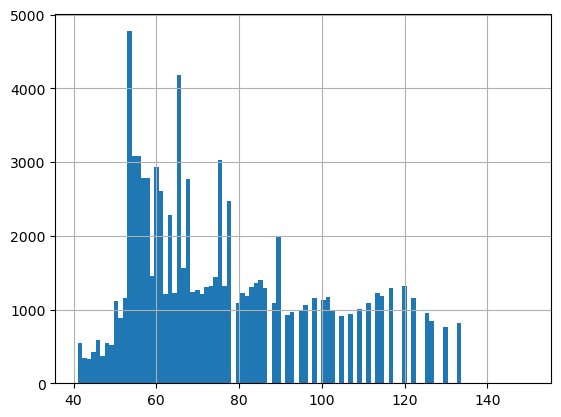

In [7]:
dff.hr.hist(bins=100)

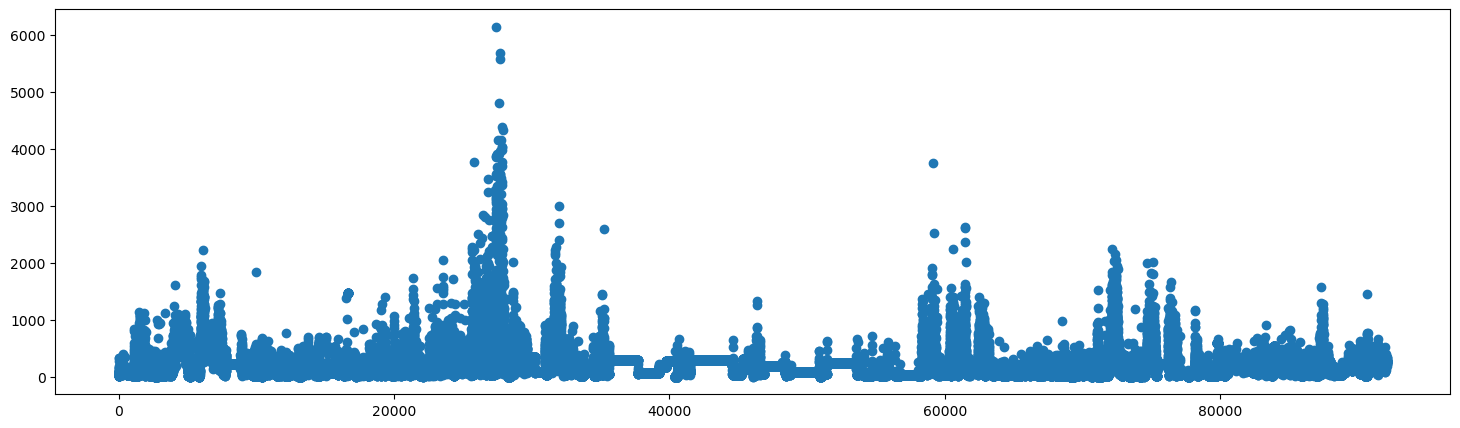

In [8]:
m = dff.motion.to_numpy()
plt.figure(figsize=(18, 5))
plt.scatter(np.arange(len(m)), m)
plt.show()

In [9]:
# 将 motion 列全体减 300，并将所有小于 0 的值限制为 0
dff['motion'] = (dff['motion'] - 300).clip(lower=0)

In [10]:
dff = dff[(dff.areaUp <= 1e5) & (dff.areaDown <= 3e5) & (dff.motion < 1500)]
dff 

,timestamp,rri,areaUp,areaDown,motion,hr
3,2026-06-10 11:31:27,500.0,1805,66610,0,120
4,2026-06-10 11:31:27,500.0,1349,52391,0,120
5,2026-06-10 11:31:27,500.0,1153,47928,0,120
6,2026-06-10 11:31:28,490.0,592,45356,38,122
7,2026-06-10 11:31:28,500.0,589,150810,0,120
...,...,...,...,...,...,...
94490,2026-06-11 17:09:04,590.0,92284,213010,0,101
94491,2026-06-11 17:09:05,760.0,12134,205505,0,78
94492,2026-06-11 17:09:06,1150.0,59513,87062,0,52
94493,2026-06-11 17:09:07,980.0,95485,77906,0,61


<Axes: >

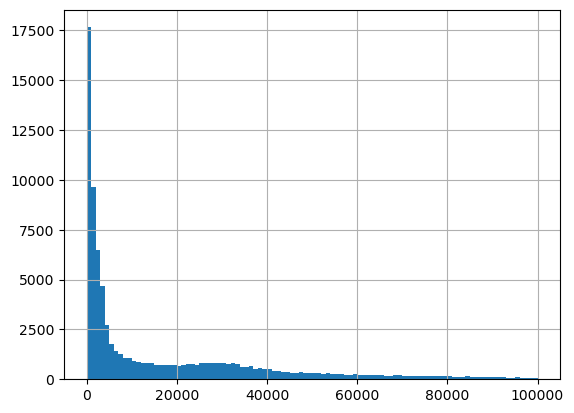

In [11]:
dff.areaUp.hist(bins=100)

In [12]:
# 1. 获取当前 areaUp 列的最小值和最大值
min_val = dff['areaUp'].min()
max_val = dff['areaUp'].max()

# 2. 执行 Min-Max 缩放 (映射到 0 - 5000 范围)
if max_val > min_val:  # 防止整列数字完全一样导致除以 0 的报错
    dff['areaUp'] = (dff['areaUp'] - min_val) / (max_val - min_val) * 5000
else:
    dff['areaUp'] = 0  # 如果全列数据一样，直接重置为 0（或者填 5000 也可以）

# 如果你需要确保最后的结果是整数 (比如为了后续的 Hex 编码)
# df['areaUp'] = df['areaUp'].round().astype(int)

In [13]:
dff[dff.areaUp == 0]

,timestamp,rri,areaUp,areaDown,motion,hr
224,2026-06-10 11:35:50,500.0,0.0,383,0,120
235,2026-06-10 11:35:58,520.0,0.0,408,0,115
334,2026-06-10 11:37:56,520.0,0.0,172,0,115
503,2026-06-10 11:40:13,500.0,0.0,1061,0,120
506,2026-06-10 11:40:15,550.0,0.0,910,0,109
...,...,...,...,...,...,...
93860,2026-06-11 16:59:11,1180.0,0.0,61142,0,50
94130,2026-06-11 17:03:25,640.0,0.0,159,0,93
94368,2026-06-11 17:07:12,970.0,0.0,14580,0,61
94385,2026-06-11 17:07:25,450.0,0.0,7203,0,133


In [14]:
# 1. 获取当前 areaUp 列的最小值和最大值
min_val = dff['areaDown'].min()
max_val = dff['areaDown'].max()

# 2. 执行 Min-Max 缩放 (映射到 0 - 5000 范围)
if max_val > min_val:  # 防止整列数字完全一样导致除以 0 的报错
    dff['areaDown'] = (dff['areaDown'] - min_val) / (max_val - min_val) * 1e4
else:
    dff['areaDown'] = 0  # 如果全列数据一样，直接重置为 0（或者填 5000 也可以）

# 如果你需要确保最后的结果是整数 (比如为了后续的 Hex 编码)
# df['areaUp'] = df['areaUp'].round().astype(int)

<Axes: >

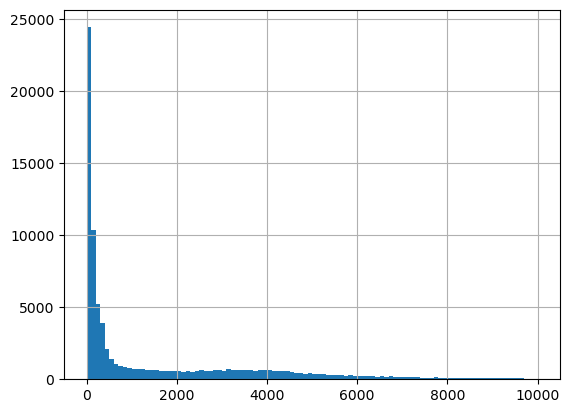

In [15]:
dff.areaDown.hist(bins=100)

In [16]:
dff.to_csv("fea_manual.csv", index=False)

In [17]:
dff.dtypes

timestamp        str
rri          float64
areaUp       float64
areaDown     float64
motion         int64
hr             int64
dtype: object

<Axes: >

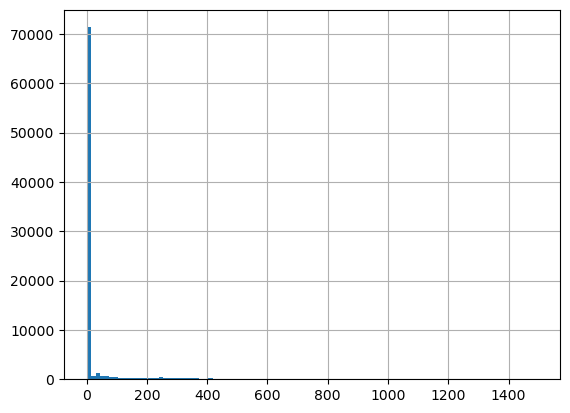

In [18]:
dff.motion.hist(bins=100)

In [19]:
dff.to_csv(r"D:\code\data\green\filtered_ppg_final_features.csv", index=False)

In [20]:
import pickle


In [21]:
fp = r"D:\code\feature_extract_pipeline\target\_target_dist_cache.pkl"
with open(fp, "rb") as f:
    target_dist_cache = pickle.load(f)

In [22]:
tar = target_dist_cache

In [23]:
tar.keys()

dict_keys(['area_up', 'area_down', 'motion'])

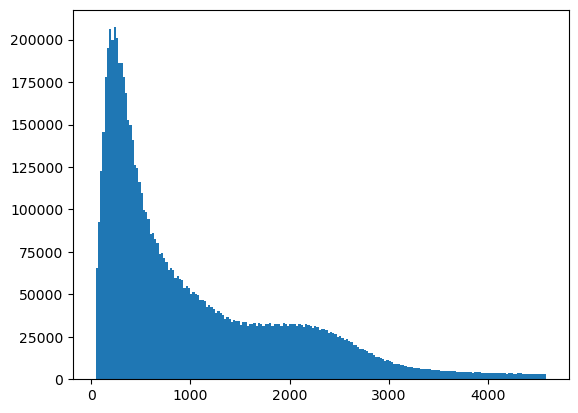

In [24]:
plt.hist(tar["area_up"], bins=200)
plt.show()

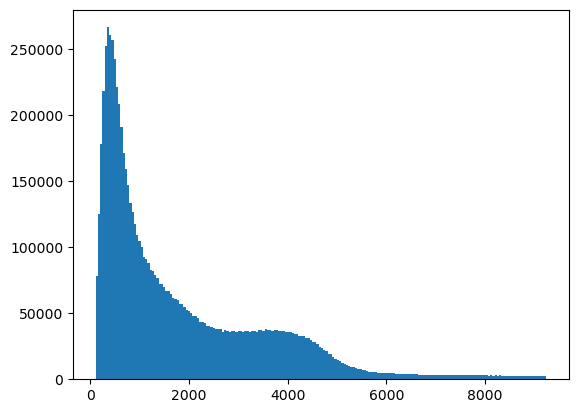

In [25]:
plt.hist(tar["area_down"], bins=200)
plt.show()

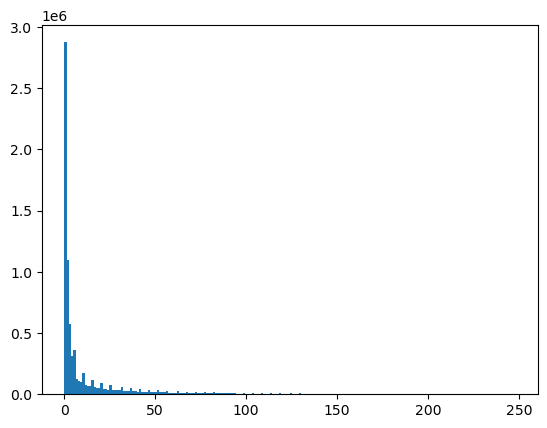

In [26]:
plt.hist(tar["motion"], bins=200)
plt.show()

In [27]:
dff.head()

,timestamp,rri,areaUp,areaDown,motion,hr
3,2026-06-10 11:31:27,500.0,90.250903,2220.977417,0,120
4,2026-06-10 11:31:27,500.0,67.450675,1746.873260,0,120
5,2026-06-10 11:31:27,500.0,57.650577,1598.063438,0,120
6,2026-06-10 11:31:28,490.0,29.600296,1512.305235,38,122
7,2026-06-10 11:31:28,500.0,29.450295,5028.458253,0,120


In [28]:
rep = r"D:\code\data\green\filtered_ppg_final_features_adapted.csv"
rf = pd.read_csv(rep)

In [29]:
rf

,timestamp,rri,areaUp,areaDown,motion,hr,areaUp_DA,areaDown_DA,motion_DA
0,2026-06-10 11:31:27,500.0,1805,66610,99,120,376.0,2437.0,99
1,2026-06-10 11:31:27,500.0,1349,52391,149,120,322.0,2167.0,149
2,2026-06-10 11:31:27,500.0,1153,47928,189,120,297.0,2090.0,189
3,2026-06-10 11:31:28,490.0,592,45356,338,122,216.0,2043.0,338
4,2026-06-10 11:31:28,500.0,589,150810,130,120,215.0,4367.0,130
...,...,...,...,...,...,...,...,...,...
82424,2026-06-11 17:09:04,590.0,92284,213010,269,101,4125.0,5759.0,269
82425,2026-06-11 17:09:05,760.0,12134,205505,269,78,968.0,5465.0,269
82426,2026-06-11 17:09:06,1150.0,59513,87062,269,52,2651.0,2894.0,269
82427,2026-06-11 17:09:07,980.0,95485,77906,269,61,4316.0,2678.0,269


<Axes: >

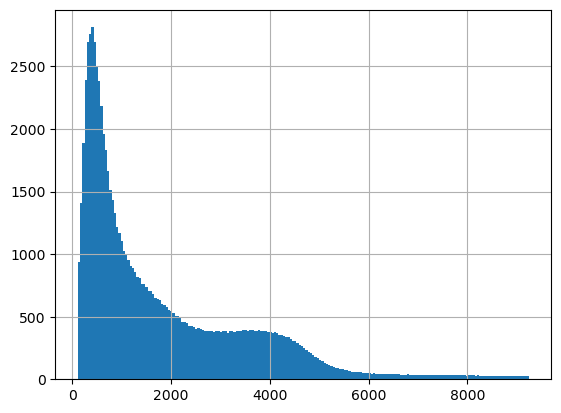

In [30]:
rf.areaDown_DA.hist(bins=200)

<Axes: >

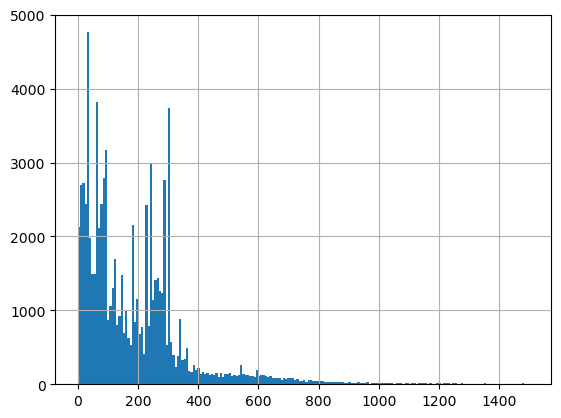

In [31]:
rf.motion_DA.hist(bins=200)

In [32]:
df.dtypes

timestamp        str
rri          float64
areaUp         int64
areaDown       int64
motion         int64
hr             int64
dtype: object

In [33]:

# 假设你的 DataFrame 变量名为 df

# 1. 将字符串格式的时间戳转换为 Datetime 格式
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 2. 按分钟 ('1min') 对数据进行重采样并求均值
# 做法是将 timestamp 设为索引，重采样后再把索引还原成列
df_minute_avg = df.set_index('timestamp').resample('1min').mean().reset_index()

# 如果你更喜欢在一行内完成，也可以使用 pd.Grouper：
# df_minute_avg = df.groupby(pd.Grouper(key='timestamp', freq='1min')).mean().reset_index()



In [34]:
df_minute_avg

,timestamp,rri,areaUp,areaDown,motion,hr
0,2026-06-10 11:31:00,758.936170,78382.340426,39470.702128,83.382979,88.127660
1,2026-06-10 11:32:00,876.944444,2224.472222,2569.500000,24.444444,76.166667
2,2026-06-10 11:33:00,795.200000,607.960000,651.906667,30.000000,81.506667
3,2026-06-10 11:34:00,848.333333,775.870370,1493.925926,30.055556,77.907407
4,2026-06-10 11:35:00,781.153846,2031.500000,2055.153846,51.461538,83.230769
...,...,...,...,...,...,...
1774,2026-06-11 17:05:00,947.936508,40569.587302,66032.523810,264.333333,66.698413
1775,2026-06-11 17:06:00,996.833333,27210.833333,51210.450000,267.150000,60.733333
1776,2026-06-11 17:07:00,931.384615,45074.169231,72632.292308,266.461538,69.338462
1777,2026-06-11 17:08:00,956.825397,52846.158730,67249.333333,271.428571,66.730159


<Axes: >

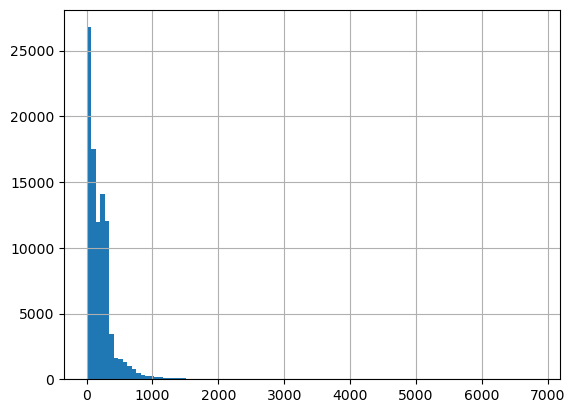

In [35]:
df.motion.hist(bins=100)

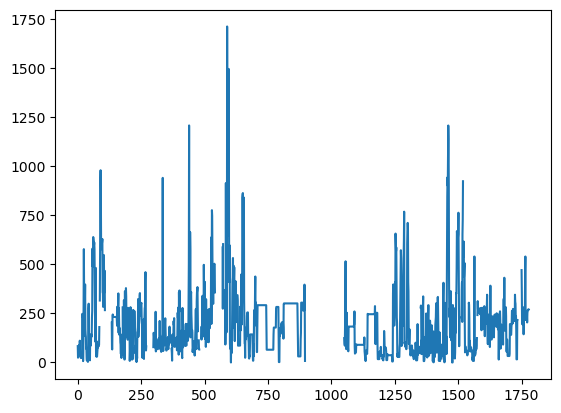

In [36]:
m = df_minute_avg.motion.to_numpy()
plt.plot(m)
plt.show()

In [37]:
fi = rf[["timestamp", "rri", "areaUp_DA", "areaDown_DA", "motion_DA"]]
fi.columns = ["timestamp", 'rri', 'areaUp', 'areaDown', 'motion']

In [38]:
fi.to_csv("onepass_feature.csv", index=False)

In [39]:
fi.dtypes

timestamp        str
rri          float64
areaUp       float64
areaDown     float64
motion         int64
dtype: object